--- Step 1: Partitioning Data ---
Training on 3281 healthy (Coswara/COUGHVID) samples.
Validating on 365 healthy (Coswara/COUGHVID) samples.
Testing on 24 healthy (Kaggle) and 30 cancer (Kaggle) samples.

--- Step 2: Setting up Feature Extractor ---

--- Step 3: Fitting Anomaly Detection Model ---


Extracting features:   0%|          | 0/3281 [00:00<?, ?it/s]


--- Step 4: Evaluating on Test Set ---


Extracting features:   0%|          | 0/24 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/30 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/365 [00:00<?, ?it/s]


--- FINAL RESULTS ---
ROC-AUC: 0.610
PR-AUC (Cancer is Positive Class): 0.649
F1-Score (at 5% FPR threshold): 0.714


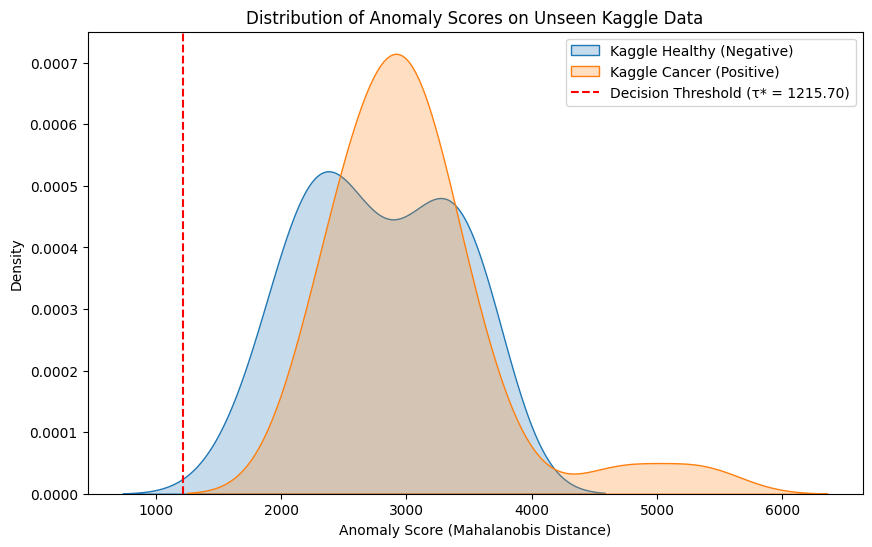

In [1]:
# ===================================================================
# CELL: One-Class Anomaly Detection Experiment
# ===================================================================
import pandas as pd
from pathlib import Path
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.io import read_image
from torchvision import models
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
# !!! IMPORTANT: Update this path to your final master metadata file !!!
MASTER_METADATA_CSV = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project_PreProess_harmonize/Project/Model_training/metadata/master_metadata_realpaths.csv"

# --- 2. DATA PARTITIONING ---
print("--- Step 1: Partitioning Data ---")
df = pd.read_csv(MASTER_METADATA_CSV)

# Training data: All healthy samples from Coswara and COUGHVID
train_df = df[
    (df['source'].isin(['Cough_Audio_Coswera', 'Cough_Audio_COUGHVID'])) &
    (df['label'] == 'healthy')
]

# Create a small validation set from the training data (e.g., 10%)
val_df = train_df.sample(frac=0.1, random_state=42)
train_df = train_df.drop(val_df.index)

# Test data: The entire Kaggle dataset (unseen source)
test_neg_df = df[df['source'] == 'kaggle_normal_raw']
test_pos_df = df[df['source'] == 'kaggle_cancer_raw']

train_healthy_paths = train_df['filepath'].tolist()
val_healthy_paths = val_df['filepath'].tolist()
test_neg_paths = test_neg_df['filepath'].tolist()
test_pos_paths = test_pos_df['filepath'].tolist()

print(f"Training on {len(train_healthy_paths)} healthy (Coswara/COUGHVID) samples.")
print(f"Validating on {len(val_healthy_paths)} healthy (Coswara/COUGHVID) samples.")
print(f"Testing on {len(test_neg_paths)} healthy (Kaggle) and {len(test_pos_paths)} cancer (Kaggle) samples.")

# --- 3. FEATURE EXTRACTOR ---
print("\n--- Step 2: Setting up Feature Extractor ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).eval().to(device)
backbone = torch.nn.Sequential(*(list(model.children())[:-1])) # Get features from penultimate layer

# Use the same transforms as your previous models for a fair comparison
tfm = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def embed(paths):
    """Function to extract features for a list of image paths."""
    feats = []
    with torch.no_grad():
        for p in tqdm(paths, desc="Extracting features"):
            # Ensure image is 3-channel
            img_tensor = read_image(str(p))
            if img_tensor.shape[0] == 1:
                img_tensor = img_tensor.repeat(3, 1, 1)
            
            x = tfm(img_tensor.float() / 255.0).unsqueeze(0).to(device)
            f = backbone(x).flatten(1).squeeze(0).cpu().numpy()
            feats.append(f)
    return np.vstack(feats)

# --- 4. ANOMALY DETECTION MODEL ---
print("\n--- Step 3: Fitting Anomaly Detection Model ---")
# Fit a Gaussian model on the features of the healthy training data
X_train = embed(train_healthy_paths)
cov = EmpiricalCovariance().fit(X_train)
mu = cov.location_
Sigma_inv = cov.precision_

def maha_score(x):
    """Calculates the squared Mahalanobis distance (anomaly score)."""
    d = x - mu
    return np.einsum('ni,ij,nj->n', d, Sigma_inv, d)

# --- 5. EVALUATION ---
print("\n--- Step 4: Evaluating on Test Set ---")
# Get anomaly scores for the unseen Kaggle data
X_neg = embed(test_neg_paths)
s_neg = maha_score(X_neg)
X_pos = embed(test_pos_paths)
s_pos = maha_score(X_pos)

# Combine for final metrics
y_true = np.concatenate([np.zeros(len(s_neg)), np.ones(len(s_pos))])
scores = np.concatenate([s_neg, s_pos]) # Higher score = more anomalous

# Determine a threshold on the validation set (target a 5% False Positive Rate)
s_val = maha_score(embed(val_healthy_paths))
tau = np.quantile(s_val, 0.95)

# Calculate metrics on the test set
roc_auc = roc_auc_score(y_true, scores)
pr_auc = average_precision_score(y_true, scores)
y_pred = (scores >= tau).astype(int)
f1 = f1_score(y_true, y_pred)

print("\n--- FINAL RESULTS ---")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC (Cancer is Positive Class): {pr_auc:.3f}")
print(f"F1-Score (at 5% FPR threshold): {f1:.3f}")

# --- 6. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.kdeplot(s_neg, label='Kaggle Healthy (Negative)', fill=True)
sns.kdeplot(s_pos, label='Kaggle Cancer (Positive)', fill=True)
plt.axvline(tau, color='r', linestyle='--', label=f'Decision Threshold (τ* = {tau:.2f})')
plt.title('Distribution of Anomaly Scores on Unseen Kaggle Data')
plt.xlabel('Anomaly Score (Mahalanobis Distance)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [2]:
pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
